In [ ]:

def Calculate_eccentricity(nodes, edges):
    adjacency_list = {node: set() for node in nodes}


    for u, v in edges:
        adjacency_list[u].add(v)
        adjacency_list[v].add(u)

    eccentricity = {}
    eccentricity_centrality = {}

# 3. Perform BFS for Every Node to Compute Eccentricity
    for source_node in nodes:
        # Reset distances for each BFS run
        distances = {node: float("inf") for node in nodes}
        distances[source_node] = 0

        visited = set([source_node])
        queue = deque([source_node])

        while queue:
            current_node = queue.popleft()

            for neighbor in adjacency_list[current_node]:
                if neighbor not in visited:
                    distances[neighbor] = distances[current_node] + 1
                    visited.add(neighbor)
                    queue.append(neighbor)  # Enqueue neighbor to continue traversal

        # Eccentricity = Maximum shortest-path distance from source_node
        max_distance = max(distances.values())
        eccentricity[source_node] = max_distance

        # Eccentricity Centrality = Reciprocal of Eccentricity
        eccentricity_centrality[source_node] = round(1.0 / max_distance, 4)
    return eccentricity_centrality, eccentricity

--- Node Eccentricities ---
{'1000 Years for Revenge': 4, 'Bush vs. the Beltway': 5, "Charlie Wilson's War": 5, 'Losing Bin Laden': 5, 'Sleeping With the Devil': 4, 'The Man Who Warned America': 4, 'Why America Slept': 4, 'Ghost Wars': 4, 'A National Party No More': 5, 'Bush Country': 5, 'Dereliction of Duty': 5, 'Legacy': 5, 'Off with Their Heads': 5, 'Persecution': 5, "Rumsfeld's War": 4, 'Breakdown': 6, 'Betrayal': 6, 'Shut Up and Sing': 6, 'Meant To Be': 5, 'The Right Man': 4, 'Ten Minutes from Normal': 5, "Hillary's Scheme": 6, 'The French Betrayal of America': 5, 'Tales from the Left Coast': 6, 'Hating America': 5, 'The Third Terrorist': 5, 'Endgame': 5, 'Spin Sisters': 6, "All the Shah's Men": 5, 'Dangerous Dimplomacy': 4, 'The Price of Loyalty': 5, 'House of Bush, House of Saud': 5, 'The Death of Right and Wrong': 6, 'Useful Idiots': 6, "The O'Reilly Factor": 7, 'Let Freedom Ring': 6, 'Those Who Trespass': 6, 'Bias': 6, 'Slander': 6, 'The Savage Nation': 6, 'Deliver Us from Evi

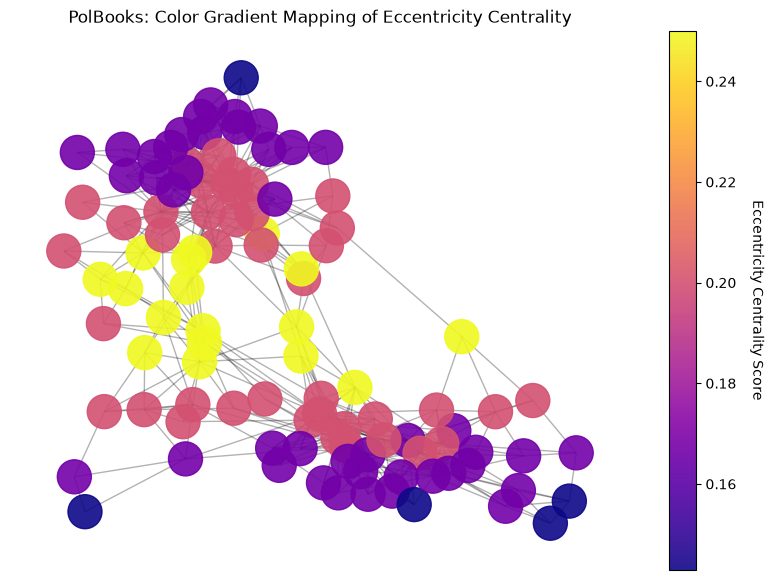

In [10]:
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt
G = nx.read_gml("polbooks.gml")

nodes = list(G.nodes())
edges = list(G.edges())

eccentricity_centrality, eccentricity = Calculate_eccentricity(nodes, edges)

print("--- Node Eccentricities ---")
print(eccentricity)

print("\n--- Top 5 Nodes by Eccentricity Centrality ---")
sorted_centrality = sorted(
    eccentricity_centrality.items(), key=lambda item: item[1], reverse=True
)
for node, centrality in sorted_centrality[:5]:
    print(f"Node: {node} | Centrality: {centrality}")

node_order = list(G.nodes())
centrality_scores = [eccentricity_centrality[node] for node in node_order]

# 3. Define layout
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 7))

# 4. Draw nodes using a color gradient ('plasma' colormap)
nodes_drawn = nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=node_order,
    node_color=centrality_scores,  # Array of numeric scores
    cmap=plt.cm.plasma,  # Color gradient palette
    node_size=600,
    alpha=0.9,
)

# 5. Draw edges and labels
nx.draw_networkx_edges(G, pos, alpha=0.3)
#nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")

# 6. Add a Colorbar legend to interpret the colors
color_bar = plt.colorbar(nodes_drawn)
color_bar.set_label("Eccentricity Centrality Score", rotation=270, labelpad=20)

plt.title("PolBooks: Color Gradient Mapping of Eccentricity Centrality")
plt.axis("off")
plt.show()

--- Node Eccentricities ---
{'Beak': 6, 'Beescratch': 5, 'Bumper': 7, 'CCL': 7, 'Cross': 8, 'DN16': 7, 'DN21': 6, 'DN63': 5, 'Double': 6, 'Feather': 7, 'Fish': 7, 'Five': 8, 'Fork': 7, 'Gallatin': 6, 'Grin': 6, 'Haecksel': 6, 'Hook': 7, 'Jet': 6, 'Jonah': 7, 'Knit': 5, 'Kringel': 6, 'MN105': 7, 'MN23': 7, 'MN60': 6, 'MN83': 7, 'Mus': 6, 'Notch': 6, 'Number1': 5, 'Oscar': 5, 'Patchback': 7, 'PL': 5, 'Quasi': 7, 'Ripplefluke': 7, 'Scabs': 6, 'Shmuddel': 7, 'SMN5': 8, 'SN100': 5, 'SN4': 6, 'SN63': 7, 'SN89': 5, 'SN9': 5, 'SN90': 6, 'SN96': 6, 'Stripes': 7, 'Thumper': 7, 'Topless': 7, 'TR120': 8, 'TR77': 6, 'TR82': 7, 'TR88': 8, 'TR99': 7, 'Trigger': 7, 'TSN103': 6, 'TSN83': 8, 'Upbang': 5, 'Vau': 7, 'Wave': 7, 'Web': 6, 'Whitetip': 8, 'Zap': 6, 'Zig': 8, 'Zipfel': 7}

--- Top 5 Nodes by Eccentricity Centrality ---
Node: Beescratch | Centrality: 0.2
Node: DN63 | Centrality: 0.2
Node: Knit | Centrality: 0.2
Node: Number1 | Centrality: 0.2
Node: Oscar | Centrality: 0.2


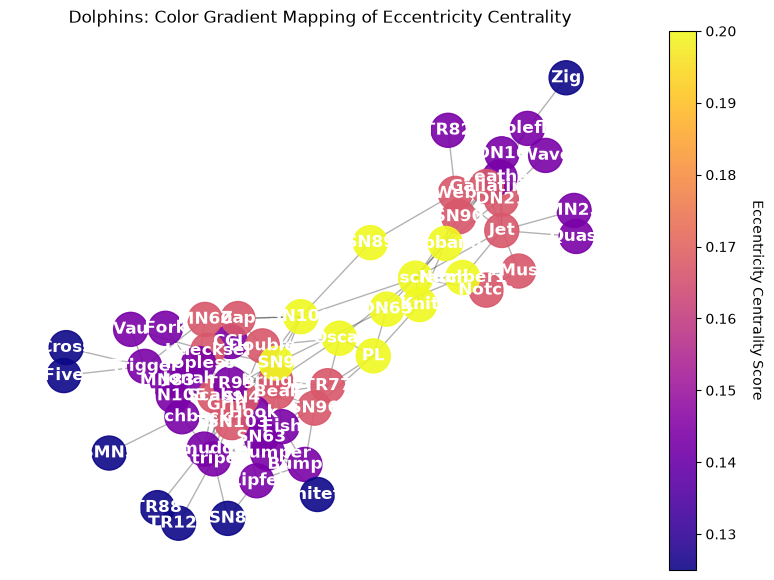

In [11]:
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt
G = nx.read_gml("dolphins.gml")

nodes = list(G.nodes())
edges = list(G.edges())

eccentricity_centrality, eccentricity = Calculate_eccentricity(nodes, edges)

print("--- Node Eccentricities ---")
print(eccentricity)

print("\n--- Top 5 Nodes by Eccentricity Centrality ---")
sorted_centrality = sorted(
    eccentricity_centrality.items(), key=lambda item: item[1], reverse=True
)
for node, centrality in sorted_centrality[:5]:
    print(f"Node: {node} | Centrality: {centrality}")

node_order = list(G.nodes())
centrality_scores = [eccentricity_centrality[node] for node in node_order]

# 3. Define layout
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 7))

# 4. Draw nodes using a color gradient ('plasma' colormap)
nodes_drawn = nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=node_order,
    node_color=centrality_scores,  # Array of numeric scores
    cmap=plt.cm.plasma,  # Color gradient palette
    node_size=600,
    alpha=0.9,
)

# 5. Draw edges and labels
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")

# 6. Add a Colorbar legend to interpret the colors
color_bar = plt.colorbar(nodes_drawn)
color_bar.set_label("Eccentricity Centrality Score", rotation=270, labelpad=20)

plt.title("Dolphins: Color Gradient Mapping of Eccentricity Centrality")
plt.axis("off")
plt.show()

In [12]:
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt
file = open('reachability.txt', 'r')
lines = file.readlines()
edges = []
for line in lines:
    line.strip()
    e = line.split(' ')
    edges.append((e[0], e[1]))

G = nx.DiGraph()
G.add_edges_from(edges)
edges = G.edges()
nodes = G.nodes()

eccentricity_centrality, eccentricity = Calculate_eccentricity(nodes, edges)

print("--- Node Eccentricities ---")

print(eccentricity)

print("\n--- Top 5 Nodes by Eccentricity Centrality ---")
sorted_centrality = sorted(
    eccentricity_centrality.items(), key=lambda item: item[1], reverse=True
)
for node, centrality in sorted_centrality[:5]:
    print(f"Node: {node} | Centrality: {centrality}")

node_order = list(G.nodes())
centrality_scores = [eccentricity_centrality[node] for node in node_order]

# 3. Define layout
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 7))

# 4. Draw nodes using a color gradient ('plasma' colormap)
nodes_drawn = nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=node_order,
    node_color=centrality_scores,  # Array of numeric scores
    cmap=plt.cm.plasma,  # Color gradient palette
    node_size=600,
    alpha=0.9,
)

# 5. Draw edges and labels
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")

# 6. Add a Colorbar legend to interpret the colors
color_bar = plt.colorbar(nodes_drawn)
color_bar.set_label("Eccentricity Centrality Score", rotation=270, labelpad=20)

plt.title("Rechability: Color Gradient Mapping of Eccentricity Centrality")
plt.axis("off")
plt.show()

--- Node Eccentricities ---
{'27': 2, '0': 2, '57': 2, '70': 2, '74': 2, '86': 2, '94': 2, '100': 2, '113': 2, '138': 2, '154': 2, '166': 2, '178': 2, '230': 2, '235': 2, '242': 2, '246': 2, '262': 2, '269': 2, '275': 2, '280': 2, '294': 2, '304': 2, '308': 2, '309': 2, '324': 2, '347': 2, '364': 2, '367': 2, '378': 2, '401': 2, '413': 2, '416': 2, '419': 2, '451': 2, '6': 2, '1': 2, '7': 2, '14': 2, '15': 2, '16': 2, '19': 2, '23': 2, '32': 2, '45': 2, '46': 2, '49': 2, '52': 2, '63': 2, '68': 2, '76': 2, '78': 2, '95': 2, '101': 2, '102': 2, '110': 2, '112': 2, '115': 2, '127': 2, '129': 2, '134': 2, '136': 2, '139': 2, '153': 2, '157': 2, '159': 2, '167': 2, '170': 2, '173': 2, '176': 2, '184': 2, '185': 2, '193': 2, '195': 2, '201': 2, '202': 2, '204': 2, '217': 2, '221': 2, '227': 2, '241': 2, '247': 2, '251': 2, '252': 2, '256': 2, '257': 2, '264': 2, '266': 2, '268': 2, '271': 2, '274': 2, '290': 2, '293': 2, '298': 2, '302': 2, '307': 2, '321': 2, '323': 2, '326': 2, '331': 2, 

KeyboardInterrupt: 

--- Node Eccentricities ---
{'BrighamYoung': 3, 'FloridaState': 4, 'Iowa': 4, 'KansasState': 3, 'NewMexico': 4, 'TexasTech': 4, 'PennState': 3, 'SouthernCalifornia': 4, 'ArizonaState': 4, 'SanDiegoState': 4, 'Baylor': 4, 'NorthTexas': 4, 'NorthernIllinois': 4, 'Northwestern': 3, 'WesternMichigan': 4, 'Wisconsin': 3, 'Wyoming': 3, 'Auburn': 3, 'Akron': 4, 'VirginiaTech': 4, 'Alabama': 4, 'UCLA': 4, 'Arizona': 4, 'Utah': 4, 'ArkansasState': 4, 'NorthCarolinaState': 4, 'BallState': 4, 'Florida': 4, 'BoiseState': 3, 'BostonCollege': 4, 'WestVirginia': 4, 'BowlingGreenState': 4, 'Michigan': 4, 'Virginia': 4, 'Buffalo': 4, 'Syracuse': 4, 'CentralFlorida': 4, 'GeorgiaTech': 4, 'CentralMichigan': 4, 'Purdue': 3, 'Colorado': 4, 'ColoradoState': 4, 'Connecticut': 4, 'EasternMichigan': 4, 'EastCarolina': 4, 'Duke': 4, 'FresnoState': 4, 'OhioState': 4, 'Houston': 4, 'Rice': 4, 'Idaho': 4, 'Washington': 4, 'Kansas': 4, 'SouthernMethodist': 4, 'Kent': 4, 'Pittsburgh': 4, 'Kentucky': 4, 'Louisville':

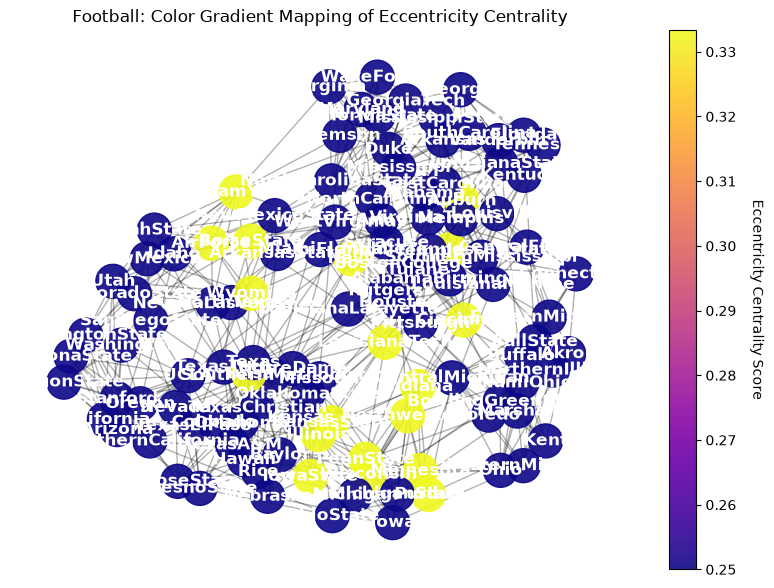

In [13]:
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt
G = nx.read_gml("football.gml")

nodes = list(G.nodes())
edges = list(G.edges())

eccentricity_centrality, eccentricity = Calculate_eccentricity(nodes, edges)

print("--- Node Eccentricities ---")
print(eccentricity)

print("\n--- Top 5 Nodes by Eccentricity Centrality ---")
sorted_centrality = sorted(
    eccentricity_centrality.items(), key=lambda item: item[1], reverse=True
)
for node, centrality in sorted_centrality[:5]:
    print(f"Node: {node} | Centrality: {centrality}")

node_order = list(G.nodes())
centrality_scores = [eccentricity_centrality[node] for node in node_order]

# 3. Define layout
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 7))

# 4. Draw nodes using a color gradient ('plasma' colormap)
nodes_drawn = nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=node_order,
    node_color=centrality_scores,  # Array of numeric scores
    cmap=plt.cm.plasma,  # Color gradient palette
    node_size=600,
    alpha=0.9,
)

# 5. Draw edges and labels
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")

# 6. Add a Colorbar legend to interpret the colors
color_bar = plt.colorbar(nodes_drawn)
color_bar.set_label("Eccentricity Centrality Score", rotation=270, labelpad=20)

plt.title("Football: Color Gradient Mapping of Eccentricity Centrality")
plt.axis("off")
plt.show()

--- Node Eccentricities ---
{0: 3, 1: 3, 2: 3, 3: 3, 4: 4, 5: 4, 6: 4, 7: 4, 8: 3, 9: 4, 10: 4, 11: 4, 12: 4, 13: 3, 14: 5, 15: 5, 16: 5, 17: 4, 18: 5, 19: 3, 20: 5, 21: 4, 22: 5, 23: 5, 24: 4, 25: 4, 26: 5, 27: 4, 28: 4, 29: 5, 30: 4, 31: 3, 32: 4, 33: 4}

--- Top 5 Nodes by Eccentricity Centrality ---
Node: 0 | Centrality: 0.3333
Node: 1 | Centrality: 0.3333
Node: 2 | Centrality: 0.3333
Node: 3 | Centrality: 0.3333
Node: 8 | Centrality: 0.3333


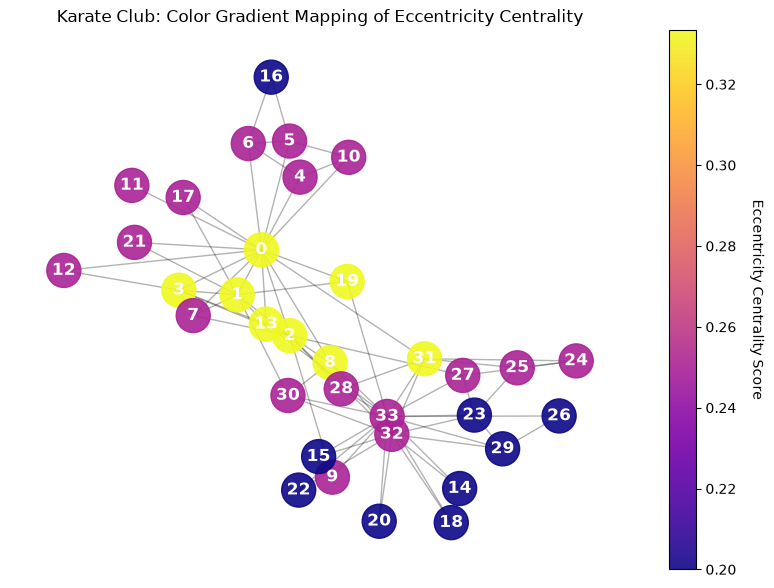

In [ ]:
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt
G = nx.karate_club_graph()

nodes = list(G.nodes())
edges = list(G.edges())

eccentricity_centrality, eccentricity = Calculate_eccentricity(nodes, edges)

print("--- Node Eccentricities ---")
print(eccentricity)

print("\n--- Top 5 Nodes by Eccentricity Centrality ---")
sorted_centrality = sorted(
    eccentricity_centrality.items(), key=lambda item: item[1], reverse=True
)
for node, centrality in sorted_centrality[:5]:
    print(f"Node: {node} | Centrality: {centrality}")


# 2. Extract values in node order
node_order = list(G.nodes())
centrality_scores = [eccentricity_centrality[node] for node in node_order]

# 3. Define layout
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 7))

# 4. Draw nodes using a color gradient ('plasma' colormap)
nodes_drawn = nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=node_order,
    node_color=centrality_scores,  # Array of numeric scores
    cmap=plt.cm.plasma,  # Color gradient palette
    node_size=600,
    alpha=0.9,
)

# 5. Draw edges and labels
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")

# 6. Add a Colorbar legend to interpret the colors
color_bar = plt.colorbar(nodes_drawn)
color_bar.set_label("Eccentricity Centrality Score", rotation=270, labelpad=20)

plt.title("Karate Club: Color Gradient Mapping of Eccentricity Centrality")
plt.axis("off")
plt.show()